# Comparison of different capabilities of recognizing language in models

1. Training of Models on english literature, german literature, third one?

(https://huggingface.co/datasets/Dorian2B/french-literature-10K)

# Loading english literature

I started with the dataset manu/project_gutenberg which contains all the books on Gutenberg


In [103]:
import random
import re
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig
import csv


The model gets tested on a number of books from the Gutenberg Project (https://www.gutenberg.org/)
Taken from the dataset manu/project_gutenberg

In [54]:
NUM_TARGET_BOOKS = 100

In [55]:
dataset = load_dataset("manu/project_gutenberg", split="en", streaming=True)

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

This dataset contains an ID and the book. The book part usually has a part that says Title: ___

In [56]:
def parse_metadata(text):
    title = "Unknown Title"
    
    title_match = re.search(r"Title:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)", text, re.IGNORECASE | re.DOTALL)
    if title_match:
        raw_title = title_match.group(1)
        title = re.sub(r'\s+', ' ', raw_title).strip()
        
    return title



In [57]:
def is_a_translation(text):
    translator_match = re.search(r"Translator:\s*(.*)", text, re.IGNORECASE)
    return translator_match is not None

Now the books are fetched and their titles and text saved

In [58]:

books = []
seen_titles = set()
iterator = iter(dataset)

while len(books) < NUM_TARGET_BOOKS:
    try:
        item = next(iterator)
        text = item["text"]
        title = parse_metadata(text)
        
        snippet_start = len(text) // 2
        snippet_end = len(text) // 2 + 1000
        snippet = text[snippet_start:snippet_end].strip()

        title_lower = title.lower()
        # Check that title was not added already (and a title exists)
        if (title != "Unknown Title" 
                and title_lower not in seen_titles and not is_a_translation(text)):
            
            seen_titles.add(title_lower)
            books.append({
                "title": title,
                "text": snippet
            })
            
    except StopIteration:
        print("Error not all books fetched")
        break


Generating multiple choice answers. 

In [59]:
evaluation_set = []
all_titles = [b["title"] for b in books]

for book in books:
    # Generate 3 wrong options
    wrong_choices = [t for t in all_titles if t != book["title"]]
    choices = random.sample(wrong_choices, 3) + [book["title"]]
    random.shuffle(choices)  # Shuffle choices
    
    correct_answer = chr(65 + choices.index(book["title"]))  # A, B, C, or D
    
    evaluation_set.append({
        "snippet": book["text"],
        "choices": choices,
        "correct_letter": correct_answer,
        "correct_title": book["title"]
    })


# Qwen 7b-Model


In [60]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto" 
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [61]:
correct_predictions = 0
failed_parses = 0

for i, item in enumerate(evaluation_set):
    prompt_choices = "\n".join([f"{chr(65 + idx)}) {choice}" for idx, choice in enumerate(item["choices"])])
    
    system_prompt = (
        "Your task is to identify which book a provided text snippet belongs to. Respond ONLY with the single letter choice (A, B, C, or D) corresponding to the correct book title. Do not output anything else."
    )
    
    user_prompt = f"\n\"\"\"\n{item['snippet']}\n\"\"\"\n\nWhich book is this snippet from?\n{prompt_choices}\n\nAnswer (A/B/C/D):"
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    text_input = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    
    model_inputs = tokenizer([text_input], return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=4,   
            temperature=0.1,
            do_sample=False     
        )

    # Decode only the newly generated tokens
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip().upper()
    
    # Extract letter from answer
    predicted_letter_match = re.search(r'[A-D]', response)
    if predicted_letter_match:
        predicted_letter = predicted_letter_match.group(0)
    else:
        predicted_letter = "Unknown"
        failed_parses += 1
    
    is_correct = (predicted_letter == item["correct_letter"])
    if is_correct:
        correct_predictions += 1

    # Track Accuracy Progress
    if (i + 1) % 10 == 0:
        current_acc = (correct_predictions / (i + 1)) * 100
        print(f"Evaluated {i+1}/{NUM_TARGET_BOOKS} | Running Accuracy: {current_acc:.1f}%")



Evaluated 10/100 | Running Accuracy: 80.0%
Evaluated 20/100 | Running Accuracy: 80.0%
Evaluated 30/100 | Running Accuracy: 83.3%
Evaluated 40/100 | Running Accuracy: 87.5%
Evaluated 50/100 | Running Accuracy: 88.0%
Evaluated 60/100 | Running Accuracy: 86.7%
Evaluated 70/100 | Running Accuracy: 88.6%
Evaluated 80/100 | Running Accuracy: 88.8%
Evaluated 90/100 | Running Accuracy: 87.8%
Evaluated 100/100 | Running Accuracy: 89.0%


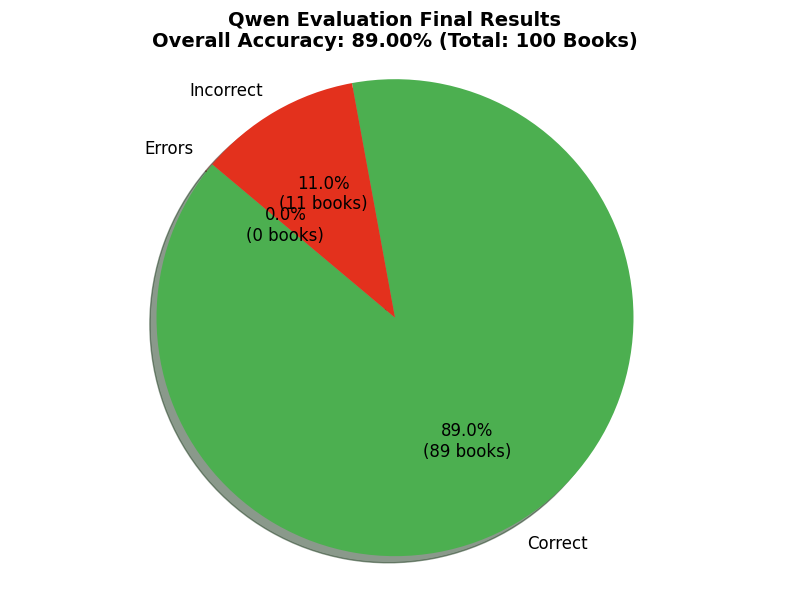

In [62]:
import matplotlib.pyplot as plt

total_questions = len(evaluation_set)
incorrect_predictions = total_questions - correct_predictions - failed_parses

# Data to plot
labels = ['Correct', 'Incorrect', 'Errors']
sizes = [correct_predictions, incorrect_predictions, failed_parses]
colors = ['#4CAF50', "#E3311D", '#FF9800'] 
# explode = (0.1, 0, 0)  

# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    sizes, 
    # explode=explode, 
    labels=labels, 
    colors=colors,
    autopct=lambda p: '{:.1f}%\n({:.0f} books)'.format(p, p * total_questions / 100),
    shadow=True, 
    startangle=140,
    textprops={'fontsize': 12}
)

# Set title with overall model accuracy
accuracy = (correct_predictions / total_questions) * 100
plt.title(f"Qwen Evaluation Final Results\nOverall Accuracy: {accuracy:.2f}% (Total: {total_questions} Books)", fontsize=14, fontweight='bold')

# Ensure the pie chart is drawn as a circle
plt.axis('equal')  

# Show the plot window
plt.tight_layout()
plt.show()


# German translations and evaluation

This section uses the manually mapped Gutenberg IDs from the CSV to:
- load German Gutenberg books,
- create a short text snippet for each book,
- build a multiple-choice task where the correct answer is the English original title,
- and evaluate the model on this task.

Die benutzte Datenbank besitzt auch ca. 3000 deutschsprachige Bücher, welche wir nun nutzen können, um diese als Übersetzungen zu behandeln. 
Dafür werden zunächst alle Bücher herausgefiltert, welche Übersetzungen vom englischen ins deutsche sind. 

In [104]:
def parse_metadata_and_id(text):
    title = "Unknown Title"
    author = "Unknown Author"
    gutenberg_id = "Unknown ID"
    
    # 1. E-Book ID extrahieren (sucht nach "[EBook #12345]" oder "[eBook #12345]")
    id_match = re.search(r"\[eBook\s+#(\d+)\]", text, re.IGNORECASE)
    if id_match:
        gutenberg_id = id_match.group(1)
        
    # 2. Titel-Block (sucht über mehrere Zeilen hinweg)
    title_match = re.search(r"Title:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)", text, re.IGNORECASE | re.DOTALL)
    if title_match:
        raw_title = title_match.group(1)
        title = re.sub(r'\s+', ' ', raw_title).strip()
        
    # 3. Autoren-Block
    author_match = re.search(r"Author:\s*(.*?)(?=\r?\n\w+:|\r?\n\r?\n)", text, re.IGNORECASE | re.DOTALL)
    if author_match:
        raw_author = author_match.group(1)
        author = re.sub(r'\s+', ' ', raw_author).strip()
        
    return gutenberg_id, title, author


In [ ]:

# 2. Übersetzungsmuster definieren
def is_translation_from_english(text, author=""):
    header_area = text[:4000].lower()
    german_translation_patterns = [
        r"aus\s+dem\s+englischen",
        r"aus\s+d\.\s+englischen",
        r"übersetzung\s+aus\s+dem\s+englischen",
        r"uebersetzung\s+aus\s+dem\s+englischen",
        r"übersetzt\s+aus\s+dem\s+englischen",
        r"uebersetzt\s+aus\s+dem\s+englischen",
        r"übertragen\s+aus\s+dem\s+englischen",
        r"uebertragen\s+aus\s+dem\s+englischen",
        r"vom\s+englischen\s+ins\s+deutsche",
        r"deutsch\s+von.*englischen",
    ]
    
    for pattern in german_translation_patterns:
        if re.search(pattern, header_area):
            return True, "Erkannt via Phrase: 'aus dem Englischen'"
            
    has_translator = "translator:" in header_area or "übersetzer:" in header_area or "uebersetzer:" in header_area
    
    if has_translator and author:
        famous_english_authors = {
            "shakespeare", "dickens", "twain", "poe", "conan doyle", "wilde", "london", "kipling",
            "wells", "austen", "bront", "shelley", "stoker", "carroll", "melville", "hawthorne", 
            "swift", "defoe", "hardy", "thackeray", "alcott", "cooper", "irving", "emerson", "whitman"
        }
        
        author_clean = author.lower()
        for eng_author in famous_english_authors:
            if eng_author in author_clean:
                return True, f"Englischer Autor ({author}) mit Übersetzer-Metadaten."
                
    return False, ""

if __name__ == "__main__":
    print("Lade den deutschen Gutenberg-Datensatz lokal herunter...")
    dataset = load_dataset("manu/project_gutenberg", split="de")
    
    translations = []
    seen_ids = set() # Wir nutzen nun IDs zur Duplikatsvermeidung!
    
    print(f"\nErfolgreich {len(dataset)} deutsche Bücher geladen. Scanne...")
    
    for item in dataset:
        text = item["text"]
        gutenberg_id, title, author = parse_metadata_and_id(text)
        
        matched, reason = is_translation_from_english(text, author)
        
        if matched:
            # Duplikatsprüfung über die eindeutige ID
            if gutenberg_id != "Unknown ID" and gutenberg_id not in seen_ids:
                seen_ids.add(gutenberg_id)
                translations.append({
                    "Gutenberg ID": gutenberg_id,
                    "Deutscher Titel": title,
                    "Autor": author,
                    "Erkennungsgrund": reason,
                    "Originaler Englischer Titel (Manuell)": "" # Hier tragen Sie den englischen Titel ein
                })
                print(f"[MATCHED] ID {gutenberg_id}: {title} von {author}")

    # Als CSV speichern mit neuer Spalte "Gutenberg ID"
    output_filename = "Gutenberg_Uebersetzungen_Liste.csv"
    fieldnames = ["Gutenberg ID", "Deutscher Titel", "Autor", "Erkennungsgrund", "Originaler Englischer Titel (Manuell)"]
    
    with open(output_filename, mode="w", encoding="utf-8-sig", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, delimiter=";")
        writer.writeheader()
        for row in translations:
            writer.writerow(row)
            
    print(f"\nFertig! {len(translations)} Übersetzungen gefunden.")
    print(f"Datei '{output_filename}' wurde erfolgreich erstellt.")

Am Ende bleiben also 28 einzigartige Übersetzungen von Englischer Literatur. Diese werden nun nach den Titeln abgeglichen und in einer CSV die englischen Titel dazugefügt. Minus der Titel die nicht im englischen Original auffindbar waren bleiben 23 Bücher.

In [88]:
import csv

with open("Gutenberg_Uebersetzungen_Liste.csv", "r") as f:
    data = csv.reader(f)

In [ ]:
import csv

def load_manually_mapped_books_csv(csv_path, original_dataset):
    print(f"Lade manuelle Zuordnungen aus {csv_path}...")

    # ID-basiertes Lookup
    title_lookup = {}
    with open(csv_path, mode="r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=";")
        
        for row in reader:
            # ID auslesen (wir konvertieren sie zur Sicherheit in einen String)
            book_id = row["Gutenberg ID"].strip() 
            german_title = row["Deutscher Titel"].strip()
            english_title = row["Originaler Englischer Titel"].strip()
            
            title_lookup[book_id] = {
                "english_title": english_title,
                "german_title": german_title
            }
    
    return title_lookup

Von den deutschen Büchern wird jetzt ebenfalls der Titel und ein Textausschnitt gesammelt.

In [100]:
import csv
from datasets import load_dataset

# Load the manually mapped German/English title pairs from the CSV
csv_path = "Gutenberg_Uebersetzungen_Liste.csv"
title_lookup = load_manually_mapped_books_csv(csv_path, None)

# Load German Gutenberg dataset
dataset = load_dataset("manu/project_gutenberg", split="de", streaming=True)

german_books = []
seen_ids = set()

iterator = iter(dataset)

while len(german_books) < len(title_lookup):
    try:
        item = next(iterator)
        text = item["text"]

        # Extract metadata
        gutenberg_id, german_title, author = parse_metadata_and_id(text)

        # Skip if not mapped in CSV
        if gutenberg_id == "Unknown ID":
            continue

        mapping = title_lookup.get(gutenberg_id)
        if not mapping:
            continue

        english_title = mapping["english_title"]
        german_title = mapping["german_title"]

        # Avoid duplicates
        if gutenberg_id in seen_ids:
            continue
        seen_ids.add(gutenberg_id)

        # Create a text excerpt of about 1000 characters
        snippet_start = len(text) // 2
        snippet_end = snippet_start + 1000
        snippet = text[snippet_start:snippet_end].strip()

        german_books.append({
            "german_title": german_title,
            "english_title": english_title,
            "text": snippet
        })

    except StopIteration:
        print("Error: not all German books could be loaded.")
        break

print(f"Loaded {len(german_books)} German books.")

Lade manuelle Zuordnungen aus Gutenberg_Uebersetzungen_Liste.csv...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 23 German books.


#### Multiple Choice for German answers

Lade manuelle Zuordnungen aus Gutenberg_Uebersetzungen_Liste.csv...
Lade den deutschen Gutenberg-Datensatz...


Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loaded 1 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Siebenter Band: enthaltend Kapitel 13 und 14.' -> 'The History of England from the Accession of James II'
Loaded 2 German books. Matched: 'Das Bildnis des Dorian Gray' -> 'The Picture of Dorian Gray'
Loaded 3 German books. Matched: 'Zwei Städte' -> 'A Tale of Two Cities'
Loaded 4 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Dritter Band' -> 'The History of England from the Accession of James II'
Loaded 5 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Erster Band enthaltend Kapitel 1 und 2' -> 'The History of England from the Accession of James II'
Loaded 6 German books. Matched: 'Geschichte von England seit der Thronbesteigung Jakob's des Zweiten. Zweiter Band' -> 'The History of England from the Accession of James II'
Loaded 7 German books. Matched: 'Geschichte von England seit der Thronbeste

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


Buch 1: Falsch! Modell wählte A, richtig war D
Buch 2: Falsch! Modell wählte A, richtig war D
Buch 3: Falsch! Modell wählte B, richtig war D
Buch 4: Falsch! Modell wählte A, richtig war C
Buch 5: Falsch! Modell wählte B, richtig war C
Buch 6: Falsch! Modell wählte A, richtig war D
Buch 7: Falsch! Modell wählte A, richtig war B
Buch 8: Falsch! Modell wählte A, richtig war D
Buch 9: Richtig! (A)
Buch 10: Falsch! Modell wählte A, richtig war C
Buch 11: Falsch! Modell wählte B, richtig war C
Buch 12: Falsch! Modell wählte A, richtig war C
Buch 13: Richtig! (A)
Buch 14: Falsch! Modell wählte A, richtig war B
Buch 15: Falsch! Modell wählte C, richtig war A
Buch 16: Falsch! Modell wählte A, richtig war D
Buch 17: Falsch! Modell wählte A, richtig war C
Buch 18: Falsch! Modell wählte A, richtig war C
Buch 19: Falsch! Modell wählte A, richtig war B
Buch 20: Falsch! Modell wählte A, richtig war C
Buch 21: Richtig! (A)
Buch 22: Falsch! Modell wählte A, richtig war B
Buch 23: Richtig! (A)


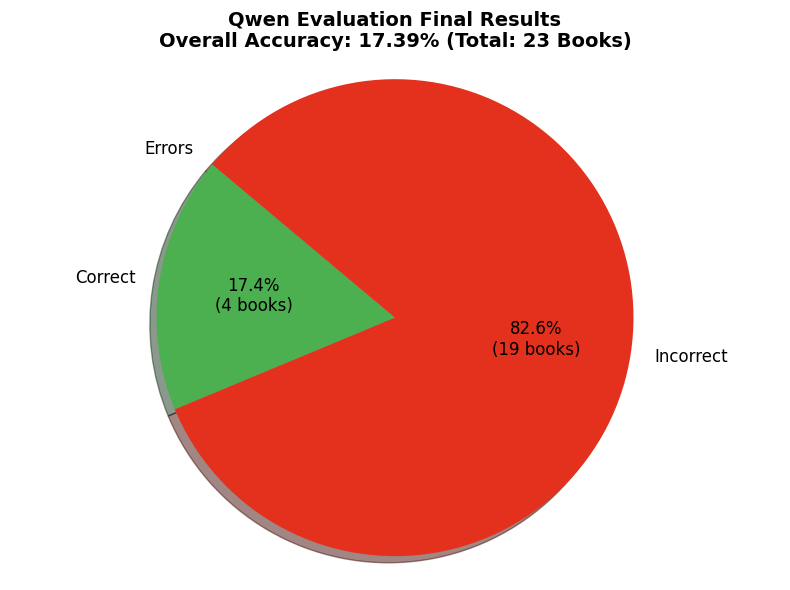

In [110]:
import random
import re
import csv
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. HELPER FUNCTIONS (RELYING ON YOUR METADATA/CSV STRUCTURE)
# -------------------------------------------------------------

def load_manually_mapped_books_csv(csv_path):
    """
    Loads manually mapped books based on Gutenberg ID.
    Delimiter is set to ';' as specified in your setup.
    """
    print(f"Lade manuelle Zuordnungen aus {csv_path}...")
    title_lookup = {}
    try:
        with open(csv_path, mode="r", encoding="utf-8-sig") as f:
            reader = csv.DictReader(f, delimiter=";")
            for row in reader:
                book_id = row["Gutenberg ID"].strip() 
                german_title = row["Deutscher Titel"].strip()
                english_title = row["Originaler Englischer Titel"].strip()
                
                title_lookup[book_id] = {
                    "english_title": english_title,
                    "german_title": german_title
                }
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")
    return title_lookup


def parse_metadata_and_id(text):
    """
    Extracts the unique Gutenberg ID, Title, and Author from raw book text.
    Gutenberg books have headers containing '[EBook #ID]' or '[eBook #ID]'.
    """
    title = "Unknown Title"
    author = "Unknown Author"
    gutenberg_id = "Unknown ID"
    
    # Extract Title
    title_match = re.search(r"Title:\s*(.*)", text, re.IGNORECASE)
    if title_match:
        title = title_match.group(1).replace("\r", "").strip()
        
    # Extract Author
    author_match = re.search(r"Author:\s*(.*)", text, re.IGNORECASE)
    if author_match:
        author = author_match.group(1).replace("\r", "").strip()
        
    # Extract Gutenberg eBook ID (e.g., [EBook #47321])
    id_match = re.search(r"\[EBook\s*#?(\d+)\]", text, re.IGNORECASE)
    if id_match:
        gutenberg_id = id_match.group(1).strip()
        
    return gutenberg_id, title, author


# -------------------------------------------------------------
# 2. DATA PREPARATION & STREAMING
# -------------------------------------------------------------

csv_path = "Gutenberg_Uebersetzungen_Liste.csv"
title_lookup = load_manually_mapped_books_csv(csv_path)

# Build a master list of all English target titles to sample distractors from
all_english_titles = list(set([item["english_title"] for item in title_lookup.values()]))

print("Lade den deutschen Gutenberg-Datensatz...")
dataset = load_dataset("manu/project_gutenberg", split="de", streaming=True)

german_books = []
seen_ids = set()
iterator = iter(dataset)

# Stream and map books by Gutenberg ID
while len(german_books) < len(title_lookup):
    try:
        item = next(iterator)
        text = item["text"]

        # Extract metadata
        gutenberg_id, german_title, author = parse_metadata_and_id(text)

        # Skip if ID cannot be parsed
        if gutenberg_id == "Unknown ID":
            continue

        # Look up metadata mapping using the Gutenberg ID
        mapping = title_lookup.get(gutenberg_id)
        if not mapping:
            continue

        english_title = mapping["english_title"]
        german_title = mapping["german_title"]

        # Avoid duplicates
        if gutenberg_id in seen_ids:
            continue
        seen_ids.add(gutenberg_id)

        # Create a text snippet of 3000 characters from the start of the book 
        # (This avoids header metadata spoiling the translation directly)
        snippet = text[1000:4000].strip()

        german_books.append({
            "german_title": german_title,
            "english_title": english_title,
            "text_snippet": snippet
        })
        print(f"Loaded {len(german_books)} German books. Matched: '{german_title}' -> '{english_title}'")

    except StopIteration:
        print("Dataset stream finished. Not all German books listed in the CSV could be loaded.")
        break

print(f"Dataset preparation done. Loaded total of {len(german_books)} books.")


# -------------------------------------------------------------
# 3. CONSTRUCT MULTIPLE CHOICE EVALUATION SET
# -------------------------------------------------------------

evaluation_set = []

for book in german_books:
    correct_title = book["english_title"]
    
    # Generate 3 wrong choices from our pooled English titles
    wrong_choices = [t for t in all_english_titles if t != correct_title]
    if len(wrong_choices) < 3:
        # Fallback if your mapping pool size is too small
        wrong_choices += ["Dummy Title A", "Dummy Title B", "Dummy Title C"]
        
    choices = random.sample(wrong_choices, 3) + [correct_title]
    random.shuffle(choices) # Shuffle choices list
    
    # Track the correct choice's label (A, B, C, or D)
    correct_idx = choices.index(correct_title)
    correct_letter = chr(65 + correct_idx)
    
    evaluation_set.append({
        "text_snippet": book["text_snippet"],
        "choices": choices,
        "correct_answer": correct_letter,
        "german_title": book["german_title"]
    })


# -------------------------------------------------------------
# 4. MODEL INITIALIZATION & EVALUATION LOOP
# -------------------------------------------------------------

model_name = "Qwen/Qwen2.5-7B-Instruct"
print(f"Lade LLM-Modell: {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype="auto", 
    device_map="auto"
)

correct_predictions = 0
failed_parses = 0

for i, item in enumerate(evaluation_set):
    # Prepare multiple choice option layout (all on 1 line to prevent syntax errors)
    prompt_choices = "\n".join([f"{chr(65 + idx)}) {choice}" for idx, choice in enumerate(item["choices"])])
    
    system_prompt = "Du bist ein hilfreicher Assistent. Lies den bereitgestellten deutschen Buchtext und finde heraus, welches der englische Originaltitel des Werkes ist."
    user_prompt = (
        f"Hier ist der Anfang eines deutschen Buches:\n\n{item['text_snippet']}\n\n"
        f"Welches ist der englische Originaltitel dieses Buches? Wähle die richtige Option:\n"
        f"{prompt_choices}\n\n"
        f"Antworte NUR mit dem korrespondierenden Großbuchstaben (A, B, C oder D)."
    )
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(**model_inputs, max_new_tokens=5, temperature=0.1)
    
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    predicted_answer = response.strip()
    match = re.search(r"\b([A-D])\b", predicted_answer)
    
    if match:
        final_prediction = match.group(1)
        if final_prediction == item["correct_answer"]:
            correct_predictions += 1
            print(f"Buch {i+1}: Richtig! ({final_prediction})")
        else:
            print(f"Buch {i+1}: Falsch! Modell wählte {final_prediction}, richtig war {item['correct_answer']}")
    else:
        failed_parses += 1
        print(f"Buch {i+1}: Parse-Fehler! Ausgabe war: '{predicted_answer}'")


# -------------------------------------------------------------
# 5. PLOT RESULTS (SAFE TO EXECUTE OUTSIDE OF THE LOOP)
# -------------------------------------------------------------

total_questions = len(evaluation_set)

if total_questions == 0:
    print("Error: No questions were successfully evaluated. Cannot generate pie chart.")
else:
    incorrect_predictions = total_questions - correct_predictions - failed_parses

    labels = ['Correct', 'Incorrect', 'Errors']
    sizes = [correct_predictions, incorrect_predictions, failed_parses]
    colors = ['#4CAF50', "#E3311D", '#FF9800']

    plt.figure(figsize=(8, 6))
    plt.pie(
        sizes, 
        labels=labels, 
        colors=colors, 
        autopct=lambda p: '{:.1f}%\n({:.0f} books)'.format(p, p * total_questions / 100) if p > 0 else '', 
        shadow=True, 
        startangle=140, 
        textprops={'fontsize': 12}
    )

    accuracy = (correct_predictions / total_questions) * 100
    plt.title(f"Qwen Evaluation Final Results\nOverall Accuracy: {accuracy:.2f}% (Total: {total_questions} Books)", fontsize=14, fontweight='bold')

    plt.axis('equal')
    plt.tight_layout()
    plt.show()